In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Initial data-quality assessment
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSummary Statistics:")
display(df.describe())

# This gives us the before-cleaning quality assessment.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          6

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Check missing-value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage.round(2)
})

missing_report

,Missing Values,Missing Percentage
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


In [6]:
# Remove duplicate rows

duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print("Duplicates before cleaning:", duplicates_before)
print("Duplicates after cleaning:", duplicates_after)

Duplicates before cleaning: 0
Duplicates after cleaning: 0


In [7]:
# Handle missing values

# Fill missing Age with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked with the most frequent value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin has many missing values, so remove the column
df = df.drop(columns=["Cabin"])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [8]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [9]:
# Standardize text values

# Remove unnecessary spaces from text columns
df["Sex"] = df["Sex"].str.strip().str.lower()
df["Embarked"] = df["Embarked"].str.strip().str.upper()

print(df["Sex"].unique())
print(df["Embarked"].unique())

['male' 'female']
['S' 'C' 'Q']


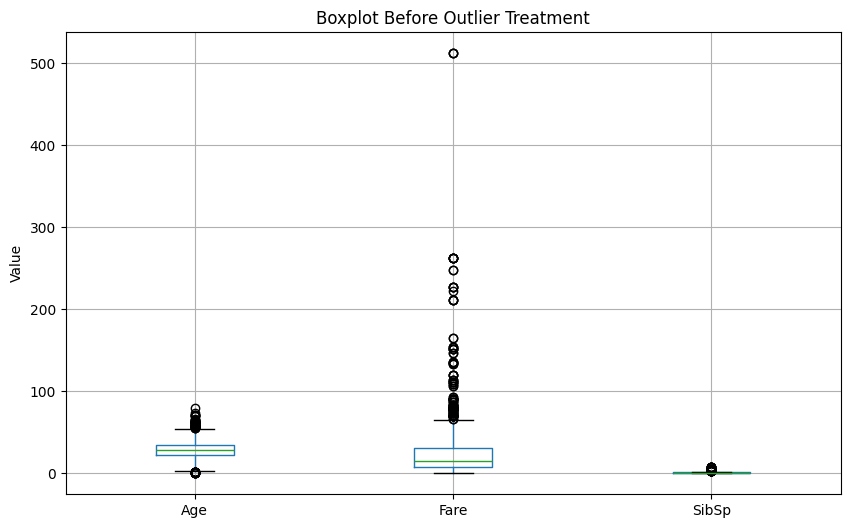

In [10]:
# Detect outliers

numeric_columns = ["Age", "Fare", "SibSp"]

plt.figure(figsize=(10, 6))

df[numeric_columns].boxplot()

plt.title("Boxplot Before Outlier Treatment")
plt.ylabel("Value")

plt.show()

In [11]:
# Treat outliers using IQR

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return data[
        (data[column] >= lower_bound) &
        (data[column] <= upper_bound)
    ]

before_outlier_treatment = len(df)

for column in numeric_columns:
    df = remove_outliers_iqr(df, column)

after_outlier_treatment = len(df)

print("Rows before outlier treatment:", before_outlier_treatment)
print("Rows after outlier treatment:", after_outlier_treatment)
print("Rows removed:", before_outlier_treatment - after_outlier_treatment)

Rows before outlier treatment: 891
Rows after outlier treatment: 689
Rows removed: 202


In [12]:
# Standardization

scaler = StandardScaler()

columns_to_scale = ["Age", "Fare", "SibSp", "Parch"]

df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.703604,1.452375,-0.357996,A/5 21171,-0.717053,S
2,3,1,3,"Heikkinen, Miss. Laina",female,-0.284241,-0.545003,-0.357996,STON/O2. 3101282,-0.665460,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.659324,1.452375,-0.357996,113803,2.787479,S
4,5,0,3,"Allen, Mr. William Henry",male,0.659324,-0.545003,-0.357996,373450,-0.655905,S
5,6,0,3,"Moran, Mr. James",male,-0.074560,-0.545003,-0.357996,330877,-0.624697,Q


In [13]:
# Before vs After comparison

print("Final Dataset Shape:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nRemaining Duplicate Rows:")
print(df.duplicated().sum())

print("\nFinal Data Types:")
print(df.dtypes)

Final Dataset Shape: (689, 11)

Remaining Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Remaining Duplicate Rows:
0

Final Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp          float64
Parch          float64
Ticket          object
Fare           float64
Embarked        object
dtype: object


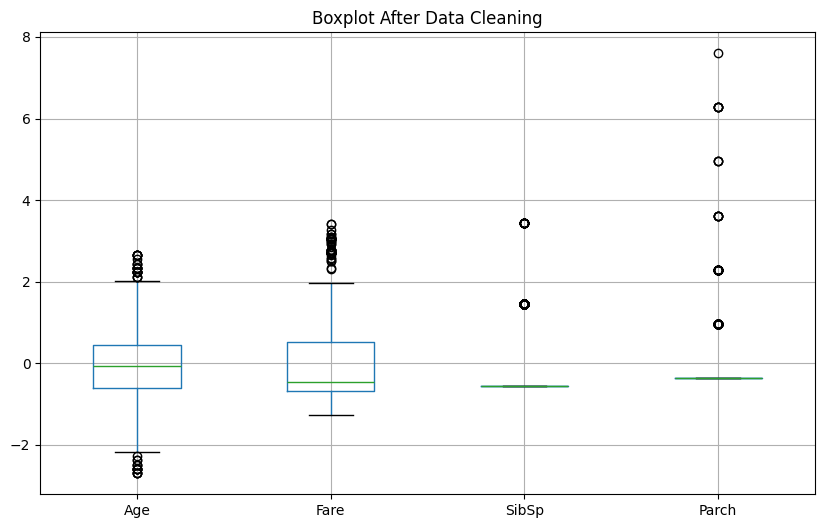

In [14]:
# Outlier check after treatment

plt.figure(figsize=(10, 6))

df[columns_to_scale].boxplot()

plt.title("Boxplot After Data Cleaning")

plt.show()

In [15]:
# Save cleaned dataset

df.to_csv("Titanic_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
